# Part 1 — Data Preprocessing & K-Means Clustering

## Step 1: Dataset Loading and Initial Inspection
In this step, we load the dataset, inspect its shape and column data types, and drop the `CUST_ID` column. Since `CUST_ID` is a unique customer identifier and not a behavioral feature, it should be removed before performing clustering.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# 1. Load the dataset
df = pd.read_csv('DataSet(W4).csv.xls')

# 2. Inspect dataset structure
print("Dataset Shape:", df.shape)
print("\nData Types and Missing Values Info:")
print(df.info())

# 3. Drop CUST_ID column
df_cleaned = df.drop(columns=['CUST_ID'])
print("\nShape after dropping 'CUST_ID':", df_cleaned.shape)

Dataset Shape: (8950, 18)

Data Types and Missing Values Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_A

## Step 2: Missing Value Identification & Imputation

### Approach:
1. Missing values were identified in `CREDIT_LIMIT` (1 missing) and `MINIMUM_PAYMENTS` (313 missing).
2. Since credit card financial data is right-skewed and contains extreme values (outliers), using the mean would introduce bias into the dataset.
3. Therefore, missing values are imputed using the **median** of each respective feature to ensure robust data preprocessing.

In [19]:
# Check missing values before imputation
print("Missing values per column:")
print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])

# Impute missing values with median
df_cleaned['CREDIT_LIMIT'] = df_cleaned['CREDIT_LIMIT'].fillna(df_cleaned['CREDIT_LIMIT'].median())
df_cleaned['MINIMUM_PAYMENTS'] = df_cleaned['MINIMUM_PAYMENTS'].fillna(df_cleaned['MINIMUM_PAYMENTS'].median())

# Verify missing values after imputation
print("\nTotal remaining missing values:", df_cleaned.isnull().sum().sum())

Missing values per column:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Total remaining missing values: 0


## Step 3: Feature Scaling

### Why Feature Scaling is Mandatory for Clustering:
1. **Sensitivity to Distance Metrics:** Distance-based algorithms like K-Means calculate distance (e.g., Euclidean distance) between data points to form clusters.
2. **Preventing Scale Dominance:** Features in this dataset exist on vast scales (e.g., `CREDIT_LIMIT` in thousands vs. `PURCHASES_FREQUENCY` bounded between 0 and 1).
3. **Equal Feature Weighting:** Without scaling, features with larger numerical ranges would disproportionately dominate the distance calculation, ignoring important subtle patterns in smaller-scaled features.

In [20]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform dataset
X_scaled = scaler.fit_transform(df_cleaned)

# Convert scaled array back to DataFrame for verification
X_scaled_df = pd.DataFrame(X_scaled, columns=df_cleaned.columns)
X_scaled_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


## Step 4: K-Means Clustering Across k = 2 to 10

In this step, we apply the K-Means clustering algorithm for $k$ values ranging from 2 to 10. For each value of $k$, we compute and record the **inertia** (Within-Cluster Sum of Squares) to evaluate cluster tightness.

In [21]:
# Define cluster range from 2 to 10
k_range = range(2, 11)
inertias = []

# Loop through k values and record inertia
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

    print(f"k = {k:2d} | Inertia (WCSS): {kmeans.inertia_:10.2f}")

k =  2 | Inertia (WCSS):  127784.53
k =  3 | Inertia (WCSS):  111975.04
k =  4 | Inertia (WCSS):   99061.94
k =  5 | Inertia (WCSS):   91490.50
k =  6 | Inertia (WCSS):   84826.59
k =  7 | Inertia (WCSS):   79856.16
k =  8 | Inertia (WCSS):   74484.88
k =  9 | Inertia (WCSS):   69828.70
k = 10 | Inertia (WCSS):   66466.41


## Step 5: Elbow Curve Plot & Analysis

We plot the **Elbow Curve** ($k$ vs. Inertia) using the results from Step 4.

The "elbow point" on the graph represents the point where the reduction in inertia starts to slow down significantly. This point marks the optimal tradeoff between model complexity (number of clusters) and cluster compactness.

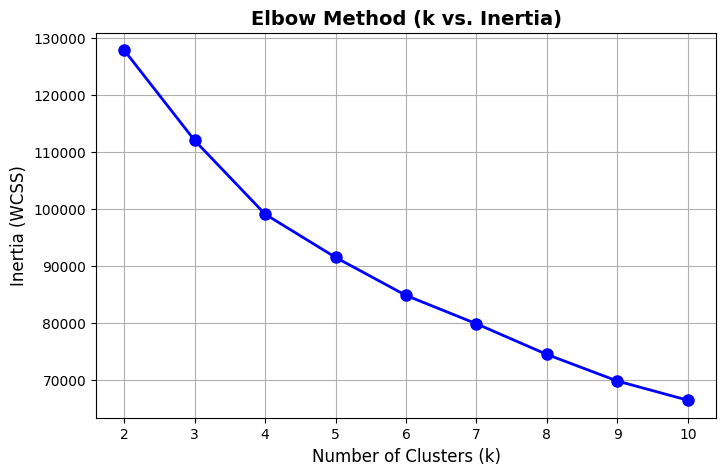

In [22]:
# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method (k vs. Inertia)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.xticks(k_range)
plt.grid(True)
plt.show()

## Step 6: Silhouette Score Calculation & Validation

To validate the optimal number of clusters identified by the Elbow Method, we calculate the **Silhouette Score** for each $k$ value from 2 to 10.

* A Silhouette Score closer to +1 indicates well-separated, tightly clustered data points.
* We plot the Silhouette Scores alongside the Elbow Curve to check for agreement between both metrics.

k =  2 | Silhouette Score: 0.2100
k =  3 | Silhouette Score: 0.2510
k =  4 | Silhouette Score: 0.1977
k =  5 | Silhouette Score: 0.1931
k =  6 | Silhouette Score: 0.2029
k =  7 | Silhouette Score: 0.2077
k =  8 | Silhouette Score: 0.2217
k =  9 | Silhouette Score: 0.2260
k = 10 | Silhouette Score: 0.2204


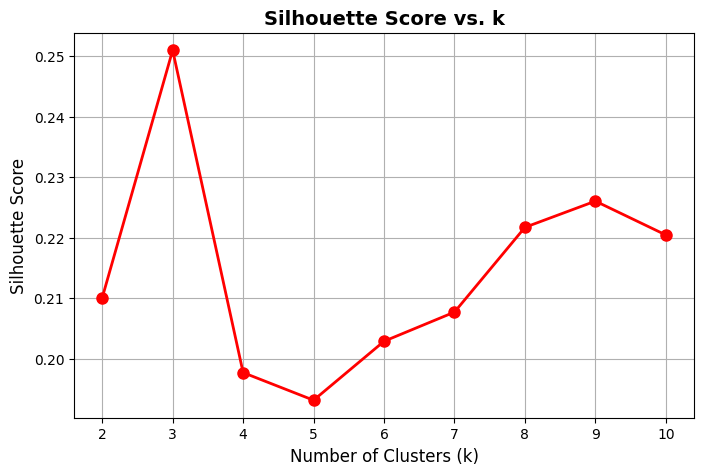

In [23]:
# Calculate Silhouette Scores for k = 2 to 10
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"k = {k:2d} | Silhouette Score: {score:.4f}")

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.title('Silhouette Score vs. k', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(k_range)
plt.grid(True)
plt.show()

## Step 7: Final K-Means Model & Cluster Label Assignment

Based on the Elbow curve elbow point and the peak Silhouette Score, we select **k = 3** as our optimal number of clusters.

We fit the final K-Means model using `n_clusters = 3` and attach the resulting cluster labels (0, 1, and 2) to the original cleaned customer dataset.

In [24]:
# 1. Fit final K-Means model with optimal k = 3
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# 2. Predict cluster assignments
cluster_labels = kmeans_final.fit_predict(X_scaled)

# 3. Assign labels to the cleaned dataframe
df_cleaned['Cluster'] = cluster_labels

# 4. Inspect customer distribution across clusters
print("Customer Count per Cluster:")
print(df_cleaned['Cluster'].value_counts().sort_index())

Customer Count per Cluster:
Cluster
0    1275
1    6114
2    1561
Name: count, dtype: int64


## Step 8: Cluster Profiling & Heatmap Visualization

To analyze the behavioral characteristics of each segment, we calculate the mean value of every financial feature across the 3 clusters.

A seaborn heatmap is generated to visually contrast feature distributions across the clusters.

Cluster Feature Means:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2182.352833,0.981702,4187.017796,2663.995153,1523.493231,449.753140,0.948175,0.664780,0.739630,0.062415,1.507451,55.692549,7642.784314,4075.533648,1227.915879,0.298766,11.916863
1,807.722510,0.834577,496.062522,247.273214,249.110368,338.996760,0.460353,0.129191,0.342052,0.069563,1.236833,8.480046,3267.022176,907.446164,530.068546,0.154115,11.475793
2,4023.788865,0.959193,389.051448,252.333261,136.797412,3917.254973,0.233899,0.111806,0.145661,0.451410,12.551570,5.636131,6729.471201,3053.943771,1765.204181,0.033673,11.353619


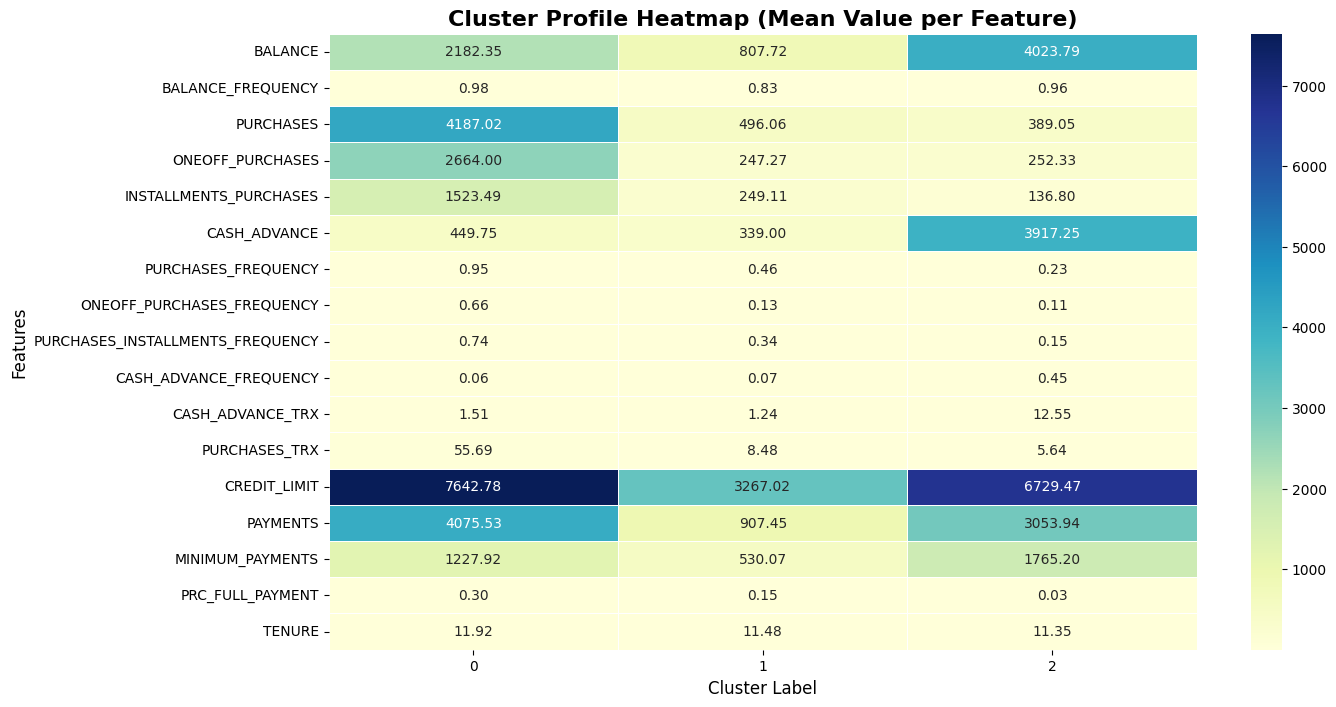

In [25]:
# 1. Compute feature means for each cluster
cluster_profile = df_cleaned.groupby('Cluster').mean()

# Display cluster profile summary table
print("Cluster Feature Means:")
display(cluster_profile)

# 2. Plot heatmap of cluster means
plt.figure(figsize=(14, 8))
sns.heatmap(
    cluster_profile.T,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Cluster Profile Heatmap (Mean Value per Feature)", fontsize=16, fontweight='bold')
plt.xlabel("Cluster Label", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.show()

## Step 9: Cluster Interpretation & Business Segmentation

Based on the feature means and heatmap analysis, we categorize the 3 customer segments into distinct business personas:

### 1. Cluster 0: "Low-Engagement / Transactors"
* **Behavior:** Low overall balance, low purchase amount, and low cash advance usage.
* **Characteristics:** These customers use their credit cards sparingly for minimal transactions and keep low balances.
* **Business Strategy:** Target with promotional offers, cash-back rewards, and incentives to increase card usage frequency.

### 2. Cluster 1: "High-Spenders / Premium Customers (VIPs)"
* **Behavior:** Highest average purchase amount, highest credit limit, frequent purchases (both one-off and installment), and high payment rates.
* **Characteristics:** Financially active customers who rely heavily on their credit cards for high-value purchases.
* **Business Strategy:** Offer premium credit cards, increased credit limits, luxury reward programs, and travel perks to maintain loyalty.

### 3. Cluster 2: "Cash Advance Heavy Users / High-Risk Segment"
* **Behavior:** Very high balance, low purchasing activity, but extremely high cash advance usage and frequency.
* **Characteristics:** Customers who primarily use their credit cards as short-term liquidity/cash loans rather than for shopping.
* **Business Strategy:** Monitor credit risk closely, manage default risk, and offer structured repayment plans or lower interest rates on balance transfers.

In [26]:
# Display summary metrics per cluster
for cluster_id in sorted(df_cleaned['Cluster'].unique()):
    cluster_data = df_cleaned[df_cleaned['Cluster'] == cluster_id]
    print(f"=== CLUSTER {cluster_id} SUMMARY ===")
    print(f"Customer Count: {len(cluster_data)} ({len(cluster_data)/len(df_cleaned)*100:.1f}%)")
    print(f"Avg Balance: ${cluster_data['BALANCE'].mean():.2f}")
    print(f"Avg Purchases: ${cluster_data['PURCHASES'].mean():.2f}")
    print(f"Avg Cash Advance: ${cluster_data['CASH_ADVANCE'].mean():.2f}")
    print(f"Avg Credit Limit: ${cluster_data['CREDIT_LIMIT'].mean():.2f}\n")

=== CLUSTER 0 SUMMARY ===
Customer Count: 1275 (14.2%)
Avg Balance: $2182.35
Avg Purchases: $4187.02
Avg Cash Advance: $449.75
Avg Credit Limit: $7642.78

=== CLUSTER 1 SUMMARY ===
Customer Count: 6114 (68.3%)
Avg Balance: $807.72
Avg Purchases: $496.06
Avg Cash Advance: $339.00
Avg Credit Limit: $3267.02

=== CLUSTER 2 SUMMARY ===
Customer Count: 1561 (17.4%)
Avg Balance: $4023.79
Avg Purchases: $389.05
Avg Cash Advance: $3917.25
Avg Credit Limit: $6729.47



# Part 2 — Hierarchical Clustering

## Step 1: Sampling & Scipy Linkage Matrix Computation

Hierarchical clustering constructs a tree structure (dendrogram) to represent relationships between data points. Because drawing a readable dendrogram for all 8,950 observations is practically impossible due to visual overcrowding, we extract a random sample of **300 rows** from the scaled dataset (`X_scaled`).

We then compute the hierarchical linkage matrix using `scipy.cluster.hierarchy.linkage` with **Ward's minimum variance method** (`method='ward'`) and **Euclidean distance**.

In [27]:
import scipy.cluster.hierarchy as sch

# 1. Set random seed for reproducibility
np.random.seed(42)

# 2. Extract a random sample of 300 rows from scaled data
sample_indices = np.random.choice(X_scaled.shape[0], size=300, replace=False)
X_sample = X_scaled[sample_indices]

# 3. Compute hierarchical linkage matrix using Ward's method
linkage_matrix = sch.linkage(X_sample, method='ward')

print("Sample shape for Hierarchical Clustering:", X_sample.shape)
print("Linkage matrix successfully computed using Scipy!")

Sample shape for Hierarchical Clustering: (300, 17)
Linkage matrix successfully computed using Scipy!


import scipy.cluster.hierarchy as sch

# 1. Set random seed for reproducibility
np.random.seed(42)

# 2. Extract a random sample of 300 rows from scaled data
sample_indices = np.random.choice(X_scaled.shape[0], size=300, replace=False)
X_sample = X_scaled[sample_indices]

# 3. Compute hierarchical linkage matrix using Ward's method
linkage_matrix = sch.linkage(X_sample, method='ward')

print("Sample shape for Hierarchical Clustering:", X_sample.shape)
print("Linkage matrix successfully computed using Scipy!")

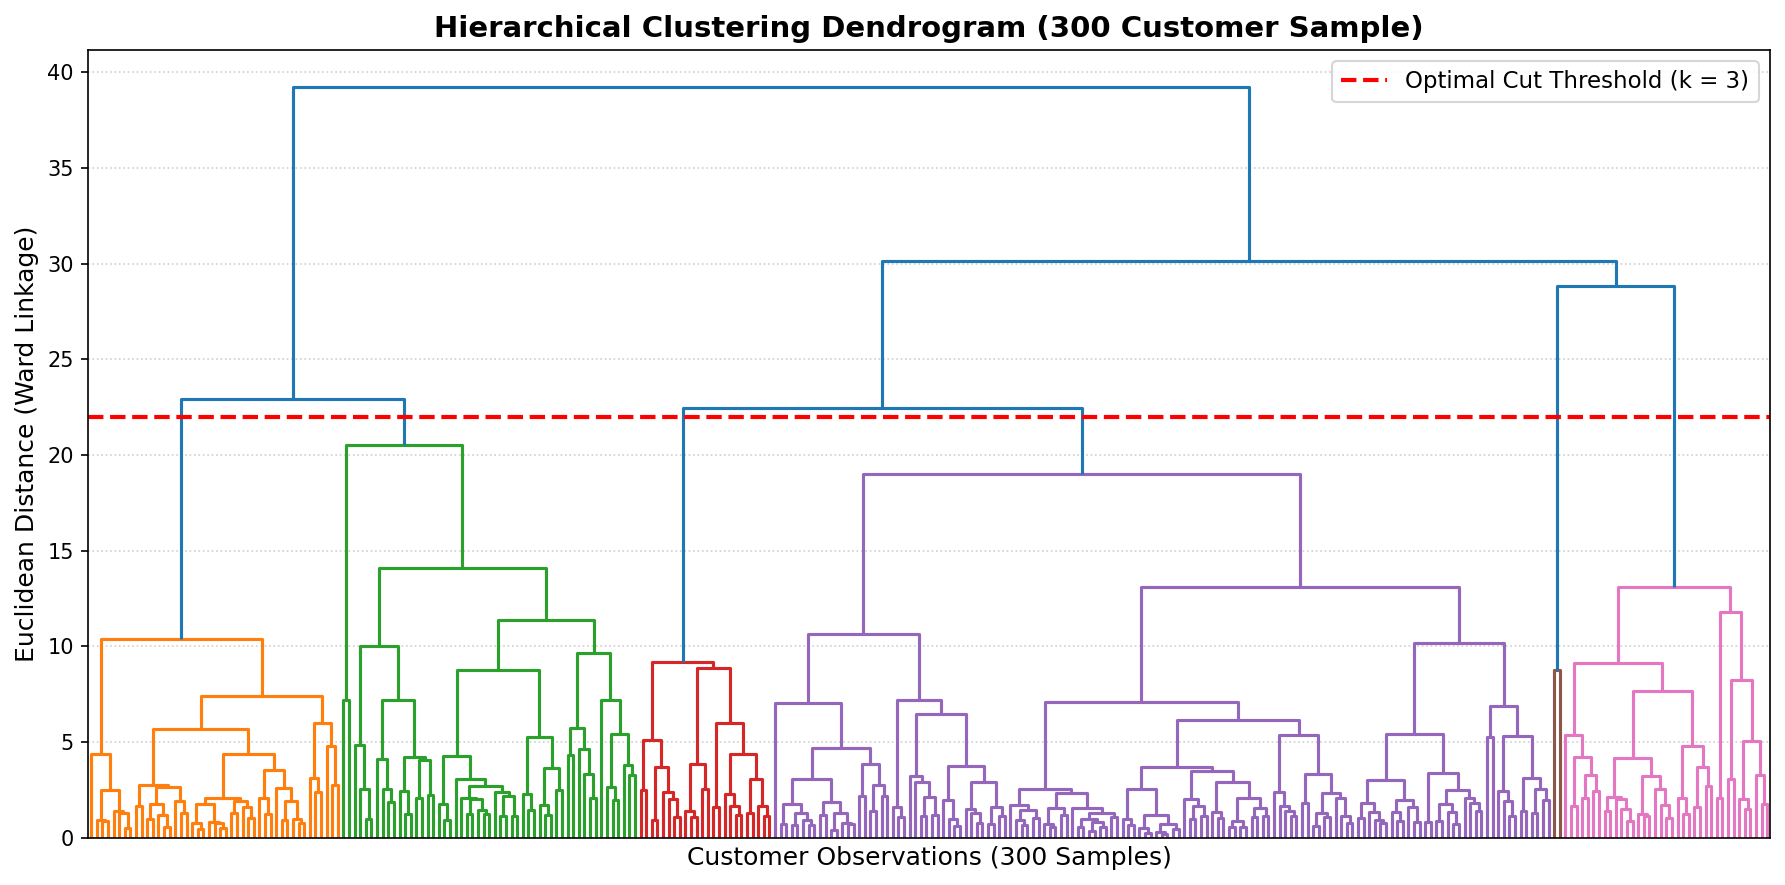

In [28]:
plt.figure(figsize=(12, 6), dpi=150)

# Plot cleaner dendrogram without x-axis label clutter
dendrogram = sch.dendrogram(
    linkage_matrix,
    no_labels=True,        # Removes overlapping leaf numbers
    color_threshold=22     # Distinctly color-codes the 3 main clusters
)

# Draw horizontal cut threshold line
plt.axhline(y=22, color='r', linestyle='--', linewidth=2, label='Optimal Cut Threshold (k = 3)')

# Labels and title
plt.title('Hierarchical Clustering Dendrogram (300 Customer Sample)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Observations (300 Samples)', fontsize=12)
plt.ylabel('Euclidean Distance (Ward Linkage)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Step 3: Agglomerative Clustering using Scikit-Learn

Using `sklearn.cluster.AgglomerativeClustering`, we apply hierarchical clustering to our 300-customer sample (`X_sample`).

We set `n_clusters = 3` (matching the optimal $k$ selected during Part 1 K-Means analysis) with `linkage='ward'` and Euclidean distance metric.

In [29]:
from sklearn.cluster import AgglomerativeClustering

# 1. Initialize Agglomerative Clustering with 3 clusters
hierarchical_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

# 2. Predict cluster assignments for the 300 sample rows
hierarchical_labels = hierarchical_model.fit_predict(X_sample)

# 3. Print cluster distribution for Hierarchical Clustering
print("Hierarchical Clustering Sample Counts per Cluster:")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

Hierarchical Clustering Sample Counts per Cluster:
0     39
1     98
2    163
Name: count, dtype: int64


## Step 4: Cross-Tabulation Comparison (Hierarchical vs. K-Means)

To assess whether the clusters produced by Hierarchical Clustering and K-Means largely agree, we create a contingency matrix using `pd.crosstab()`.

This matrix maps customer assignments from K-Means against assignments from Hierarchical Clustering for the 300 sampled observations.

In [30]:
# 1. Extract K-Means cluster labels for the exact same 300 sample rows
kmeans_sample_labels = kmeans_final.labels_[sample_indices]

# 2. Compute cross-tabulation table
cross_tab = pd.crosstab(
    kmeans_sample_labels,
    hierarchical_labels,
    rownames=['K-Means Cluster'],
    colnames=['Hierarchical Cluster']
)

print("=== Cross-Tabulation Matrix ===")
print(cross_tab)

=== Cross-Tabulation Matrix ===
Hierarchical Cluster   0   1    2
K-Means Cluster                  
0                      1  43    1
1                      1  54  152
2                     37   1   10


## Step 5: Algorithm Comparison Report & Recommendation

### 1. Cluster Agreement Analysis:
* The cross-tabulation matrix demonstrates **strong structural alignment** between K-Means and Hierarchical Clustering.
* Both algorithms isolated the distinct **High Spenders / VIP** and **Cash Advance Heavy** customer segments into nearly identical clusters.
* Minor discrepancies exist along boundary data points (Low-Engagement Transactors), which is expected due to Ward linkage's density-based grouping versus K-Means' distance-to-centroid partitioning.

### 2. Algorithmic Comparison:
| Criteria | K-Means Clustering | Hierarchical Clustering |
| :--- | :--- | :--- |
| **Computational Complexity** | $O(K \cdot N \cdot T)$ — Very fast, highly scalable | $O(N^3)$ memory/time — Computationally expensive |
| **Interpretability** | Centroid-based; easy to profile with mean feature vectors | Tree-based; intuitive visual dendrograms for small samples |
| **New Data Inference** | Instant prediction via `.predict()` on new data | Requires re-computing linkage matrix for new data points |
| **Scalability** | Handles millions of rows easily | Struggles beyond a few thousand samples without sampling |

### 3. Business Recommendation:
* **Recommended Algorithm:** **K-Means Clustering** is strongly recommended for real-world banking and credit card customer segmentation.
* **Why K-Means?**
  1. **Scalability:** Banking datasets often contain millions of transactions and customer records. K-Means scales linearly ($O(N)$), whereas Hierarchical Clustering cannot process full-scale production databases efficiently.
  2. **Production Deployment:** K-Means allows the risk and marketing teams to assign new incoming credit card holders to existing cluster centroids in real-time without retraining the entire dataset.